**Multiarmed bandit**

A multiarmed bandit is a problem where you have a set of actions, and you want to maximize your reward over time. The name comes from the idea of a slot machine (sometimes called a "one-armed bandit"), where you have to choose which arm of the slot machine to pull. Each arm has a reward distribution (unknown to you) that gives you a reward each time you pull that arm. In this problem, the question is: which arm do you choose, and how many times do you pull it?

Let us start with the imports. We use only numpy and matplotlib, and use the magic command `%matplotlib inline` to display the plots in the notebook.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib inline

The next thing we do is to seed the random number generator. This is done to ensure that the results are reproducible. At this point, this is not strictly necessary, but it is good practice to do so (and when working with Deep Reinforcement Learning, it is absolutely necessary).

In [34]:
rng = np.random.default_rng(1234)

Now, let us define the parameters of the problem. We have a set of bandits (2 in this case), each with a mean reward. We will use a Gaussian distribution for the reward, with a standard deviation of 1. We will also define the number of steps we will take, and the epsilon-greedy parameter.

In [35]:
nb = 2  # Number of bandits
m = [10, 30]  # Mean of each bandit
n_steps = 100
r = [0.1, 0]  #Epsilon-greedy values
rew = rng.multivariate_normal(m, np.eye(nb), size=n_steps)

Now, let us run the algorithm. We will use a simple epsilon-greedy algorithm, where we choose the best arm with probability $1-\epsilon$, and a random arm with probability $\epsilon$. We will also keep track of the cumulative reward over time. Note that, since this is an exercise, you will have to fill in the blanks in the code below.

In [36]:
win = np.zeros((len(r), n_steps))

for i, eps in enumerate(r):
    Q = np.zeros(nb)
    N = np.zeros(nb)
    for t in range(n_steps):
        # Code to be filled by the student: select the action a adequately
        p = rng.random()
        if p < eps:
          a = np.random.choice(2)
        else:
          a = np.argmax(Q)

        # Update
        N[a] += 1
        Q[a] += (rew[t, a] - Q[a]) / N[a]
        win[i, t] = rew[t, a]
print(win)

[[ 8.39616319 10.7408913  10.86374389  8.52117664  8.33386454  9.48755629
   9.13971981 27.84086099 31.73328932 28.99783421 30.7671747  28.84258919
  30.35138369 30.01318158  9.32075003 30.25883851 27.50821038 29.49449087
  28.66967158 29.75278499 28.66484713 31.1148069  31.59011208  9.51267482
  10.51309021 30.6488165  29.98902174 30.89578643 32.79962711 30.848107
  29.91555836 29.83619422 29.28756034 30.47526795 29.86335634 29.91178165
  30.96340988 30.93715039 30.09806809 28.22012211 29.85093222 30.13101789
  32.89430742 30.17145582 31.65268582 31.52456461 28.67817398 31.11738076
  30.96405306 29.50871714 30.1616142  28.41989053 30.72186786  9.41636796
  10.50536578 29.44563539 28.30135308 29.48428361 31.3425741  28.14810517
  28.89508381 30.15826595 28.68028406 32.11976386 30.32569785 29.72968093
  30.0828318  29.69179285 29.64301988 29.923782   30.9609381  30.40407413
  29.75109701 30.39060843 30.39309989 29.25174104 30.65737555 30.31727926
  29.33434988 30.03640254 29.52200954 29

Finally, let us plot the results. We will plot the cumulative reward over time, for each of the algorithms. We will also plot the maximum gain, to see how far we are from the optimal solution. Note that the results show that the deterministic exploration is better than the no exploration case, but it is not the maximum gain (which is achieved by pulling the best arm every time, and that requires knowing the mean of each arm).

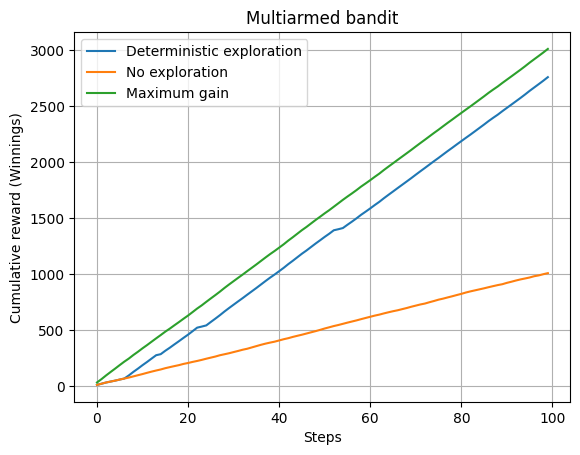

In [37]:
plt.plot(np.cumsum(win[0, :]), label="Deterministic exploration")
plt.plot(np.cumsum(win[1, :]), label="No exploration")
plt.plot(np.cumsum(np.max(rew, axis=1)), label="Maximum gain")
plt.xlabel("Steps")
plt.ylabel("Cumulative reward (Winnings)")
plt.title('Multiarmed bandit')
plt.grid()
plt.legend()
plt.show()